### initialize env & comfyui lib ###

In [4]:
!pip3 install websocket-client
!pip3 install -U requests

In [1]:
import sagemaker
import boto3
from sagemaker import get_execution_role

sess = sagemaker.Session()
role = get_execution_role()
sagemaker_default_bucket = sess.default_bucket()

account = sess.boto_session.client("sts").get_caller_identity()["Account"]
region = sess.boto_session.region_name

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


### funcs for comfyui

In [12]:
import websocket
import uuid
import json
import urllib.request
import urllib.parse
import base64
import time

#server_address = "ec2-34-222-223-235.us-west-2.compute.amazonaws.com:8188"
server_address = "comfyui-alb-905118004.us-west-2.elb.amazonaws.com:8080"
client_id = str(uuid.uuid4())

def queue_prompt(prompt):
    #print(prompt)
    p = {"prompt": prompt, "client_id": client_id}
    data = json.dumps(p).encode('utf-8')
    url = "http://"+server_address+"/prompt"
    req = urllib.request.Request(url, data=data)
    #req =  urllib.request.Request("http://ec2-34-222-223-235.us-west-2.compute.amazonaws.com:8188/prompt", data=data)
    return json.loads(urllib.request.urlopen(req).read())

def get_image_privew(filename):
    url = "http://{}/view?filename={}&type=output".format(server_address,filename)
    with urllib.request.urlopen(url) as response:
        return response.read()

def get_image(filename, subfolder, folder_type):
    data = {"filename": filename, "subfolder": subfolder, "type": folder_type}
    url_values = urllib.parse.urlencode(data)
    with urllib.request.urlopen("http://{}/view?{}".format(server_address, url_values)) as response:
        return response.read()

def get_history(prompt_id):
    with urllib.request.urlopen("http://{}/history/{}".format(server_address, prompt_id)) as response:
        return json.loads(response.read())

    
def get_videos_by_prompt_id(prompt_id):
    output_images={}
    while True:
        try:
            history = get_history(prompt_id)[prompt_id]
            for o in history['outputs']:
                #print("output==",o)
                for node_id in history['outputs']:
                    node_output = history['outputs'][node_id]
                    #print("node_output",node_output)
                    # video branch
                    if 'gifs' in node_output:
                        videos_output = []
                        for video in node_output['gifs']:
                            video_data = get_image(video['filename'], video['subfolder'], video['type'])
                            videos_output.append(video_data)
                        output_images[node_id] = videos_output
            break
        except Exception as e:
            print("waiting to get execution history:",e)
            time.sleep(5)
            continue
        
        
    
    return output_images
    
    
    
    
def get_images_by_prompt_id(prompt_id):
    output_images={}
    while True:
        try:
            history = get_history(prompt_id)[prompt_id]
            for o in history['outputs']:
                #print("output==",o)
                for node_id in history['outputs']:
                    node_output = history['outputs'][node_id]
                    if 'images' in node_output:
                        images_output = []
                        for image in node_output['images']:
                            image_data = get_image(image['filename'], image['subfolder'], image['type'])
                            images_output.append(image_data)
                        output_images[node_id] = images_output
                    # video branch
                    if 'gifs' in node_output:
                        videos_output = []
                        for video in node_output['gifs']:
                            video_data = get_image(video['filename'], video['subfolder'], video['type'])
                            videos_output.append(video_data)
                        output_images[node_id] = videos_output
            break
        except Exception as e:
            print("waiting to get execution history:",e)
            time.sleep(5)
            continue
        
        
    
    return output_images



def get_images(ws, prompt):
    prompt_id = queue_prompt(prompt)['prompt_id']
    print("prompt_id=="+prompt_id)
    output_images = {}
    if ws:
        while True:
            out = ws.recv()
            if isinstance(out, str):
                message = json.loads(out)
                if message['type'] == 'executing':
                    data = message['data']
                    if data['node'] is None and data['prompt_id'] == prompt_id:
                        break #Execution is done
            else:
                continue #previews are binary data
    else:
        pass

    history = get_history(prompt_id)[prompt_id]
    for o in history['outputs']:
        print("output==")
        print(o)
        for node_id in history['outputs']:
            node_output = history['outputs'][node_id]
            if 'images' in node_output:
                images_output = []
                for image in node_output['images']:
                    image_data = get_image(image['filename'], image['subfolder'], image['type'])
                    #image_data = get_image_privew(image['filename'])
                    print("image data==\n")
                    #image_text = (image_data).decode('utf-8') 
                    print(image_data)
                    images_output.append(image_data)
                output_images[node_id] = images_output
            # video branch
            if 'gifs' in node_output:
                videos_output = []
                for video in node_output['gifs']:
                    video_data = get_image(video['filename'], video['subfolder'], video['type'])
                    videos_output.append(video_data)
                output_images[node_id] = videos_output

    return output_images

### 生图 test

* for image translate

In [7]:
prompt_json_file="./sample_workflows/img_translate_workflow_api.json"
source_img = "./textract_demo_015.png"

import uuid
import json
import base64

def image_to_base64(image_path):
    try:
        with open(image_path, "rb") as image_file:
            # 读取图像文件
            image_data = image_file.read()
            # 将图像数据转换为Base64编码
            base64_encoded = base64.b64encode(image_data).decode('utf-8')
            return base64_encoded
    except IOError:
        print(f"无法读取文件: {image_path}")
        return None

# 使用你提供的图像路径
image_path = "./textract_demo_015.png"
base64_string = image_to_base64(image_path)


prompt_text=""
with open(prompt_json_file) as f:
    prompt_text = json.load(f)

prompt_text['81']['inputs']['image']= base64_string

* for 换品种

In [20]:
import uuid
import json
import base64

def image_to_base64(image_path):
    try:
        with open(image_path, "rb") as image_file:
            # 读取图像文件
            image_data = image_file.read()
            # 将图像数据转换为Base64编码
            base64_encoded = base64.b64encode(image_data).decode('utf-8')
            return base64_encoded
    except IOError:
        print(f"无法读取文件: {image_path}")
        return None

## for 换品种
prompt_json_file="./sample_workflows/20240224.json"
image_path = "./20241219.png"
base64_string = image_to_base64(image_path)
prompt_text=""
with open(prompt_json_file) as f:
    prompt_text = json.load(f)

## for 换品种
prompt_text['28']['inputs']['text']= "a BASSET HOUND dog"
prompt_text['63']['inputs']['base64_data']=base64_string



* for 换风格

In [21]:
import uuid
import json
import base64

def image_to_base64(image_path):
    try:
        with open(image_path, "rb") as image_file:
            # 读取图像文件
            image_data = image_file.read()
            # 将图像数据转换为Base64编码
            base64_encoded = base64.b64encode(image_data).decode('utf-8')
            return base64_encoded
    except IOError:
        print(f"无法读取文件: {image_path}")
        return None

## for 换风格
prompt_json_file="./sample_workflows/new_lora_api.json"
#image_path = "./20241219.png"

#base64_string = image_to_base64(image_path)
with open(prompt_json_file) as f:
    prompt_text = json.load(f)

## for 换风格
#prompt_text['6']['inputs']['text']= "USTRALIAN CATTLE dog in realist style"
#prompt_text['49']['inputs']['base64_data']=base64_string

* begin

In [13]:

#ws = websocket.WebSocket()
#ws.connect("ws://{}/ws?clientId={}".format(server_address, client_id))
prompt_id=queue_prompt(prompt_text)['prompt_id']
print("prompt_id",prompt_id)


prompt_id 669da825-b3dd-40b3-b058-b20dfe659995


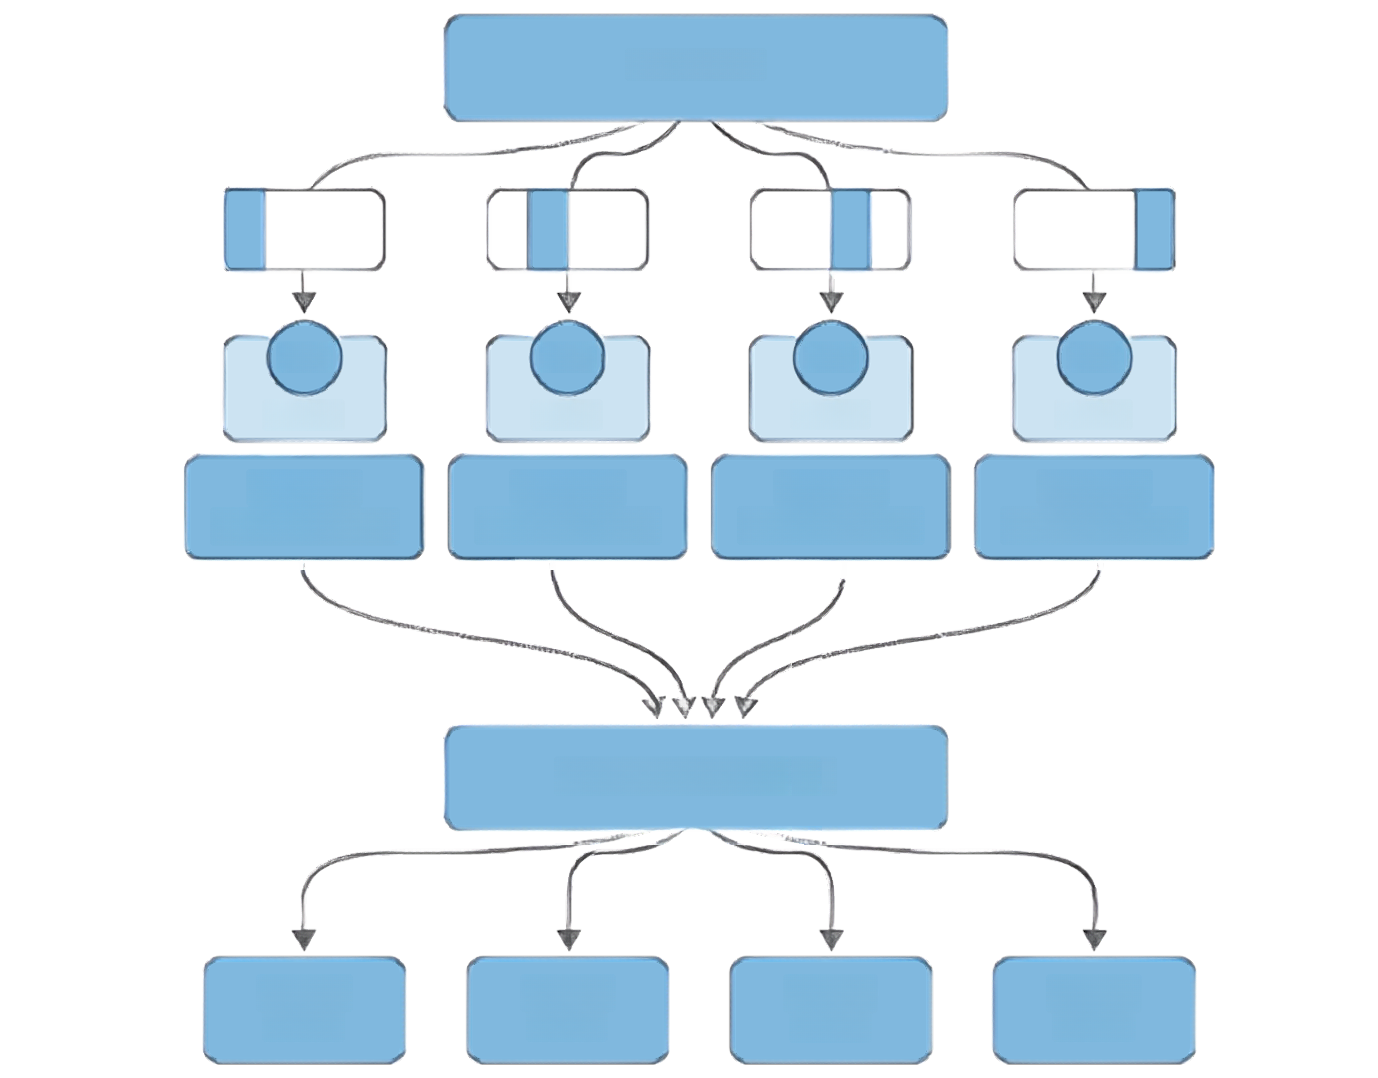

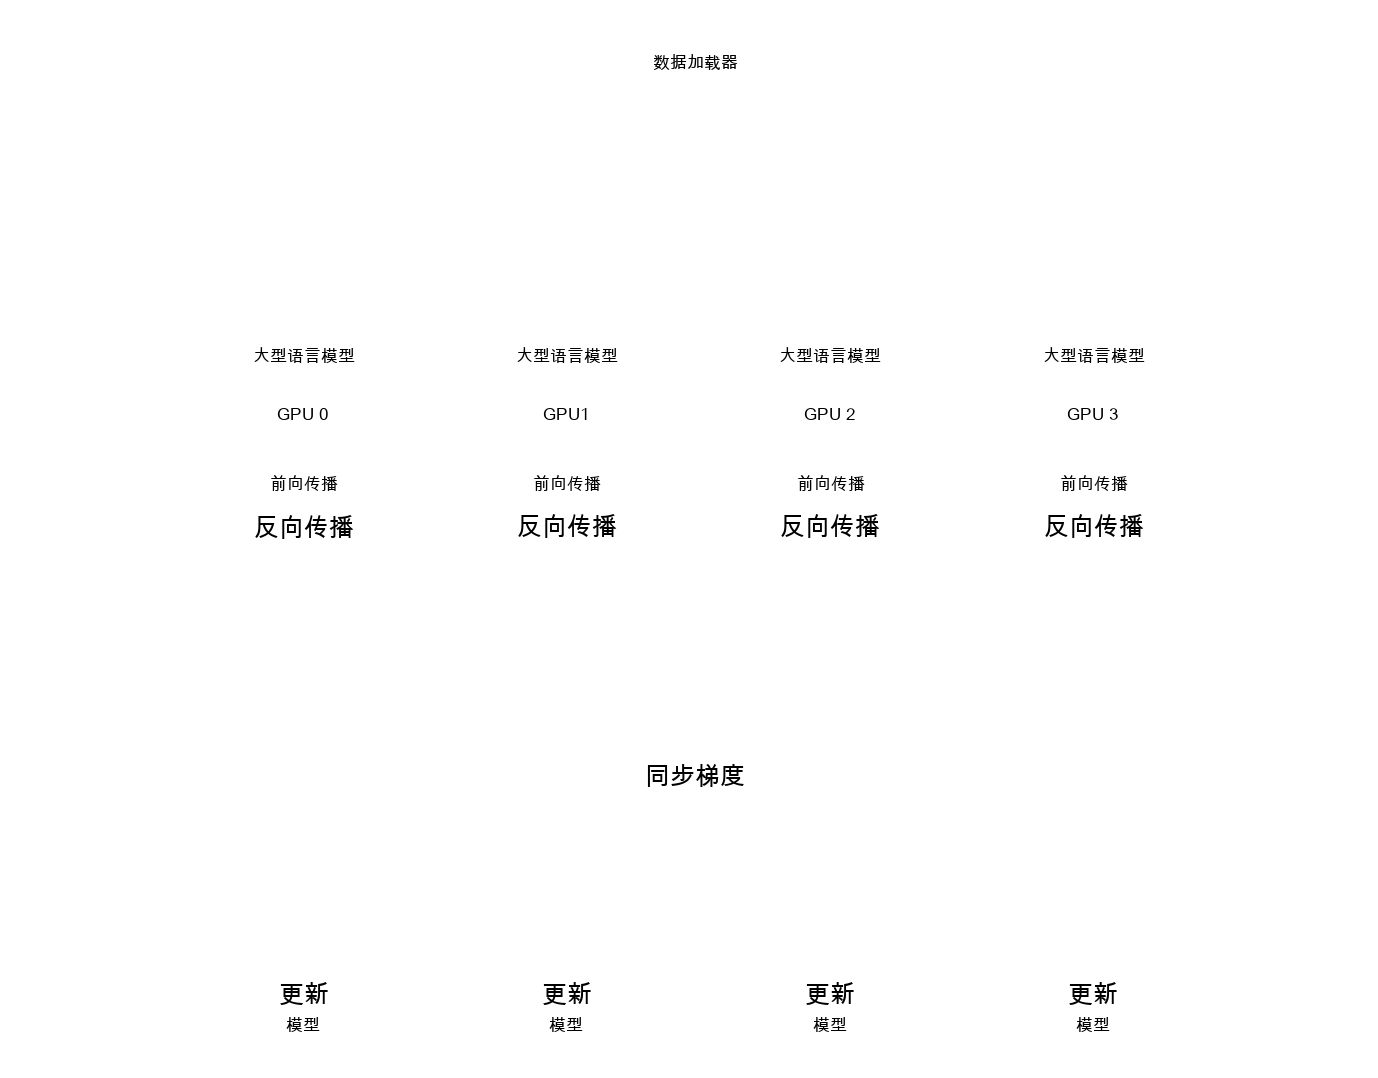

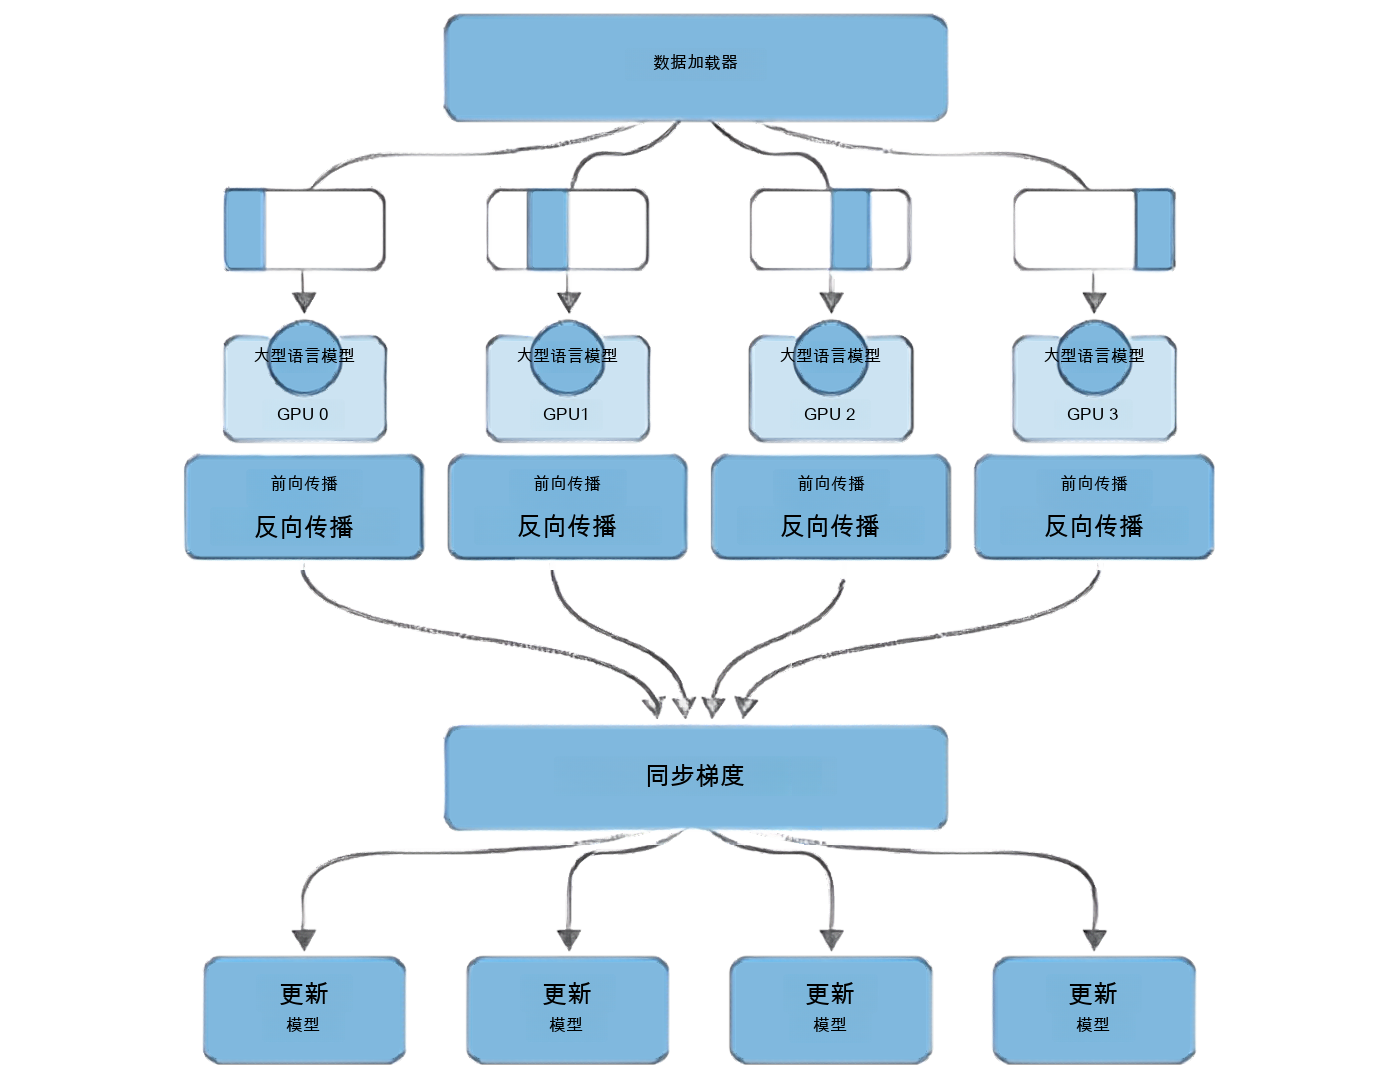

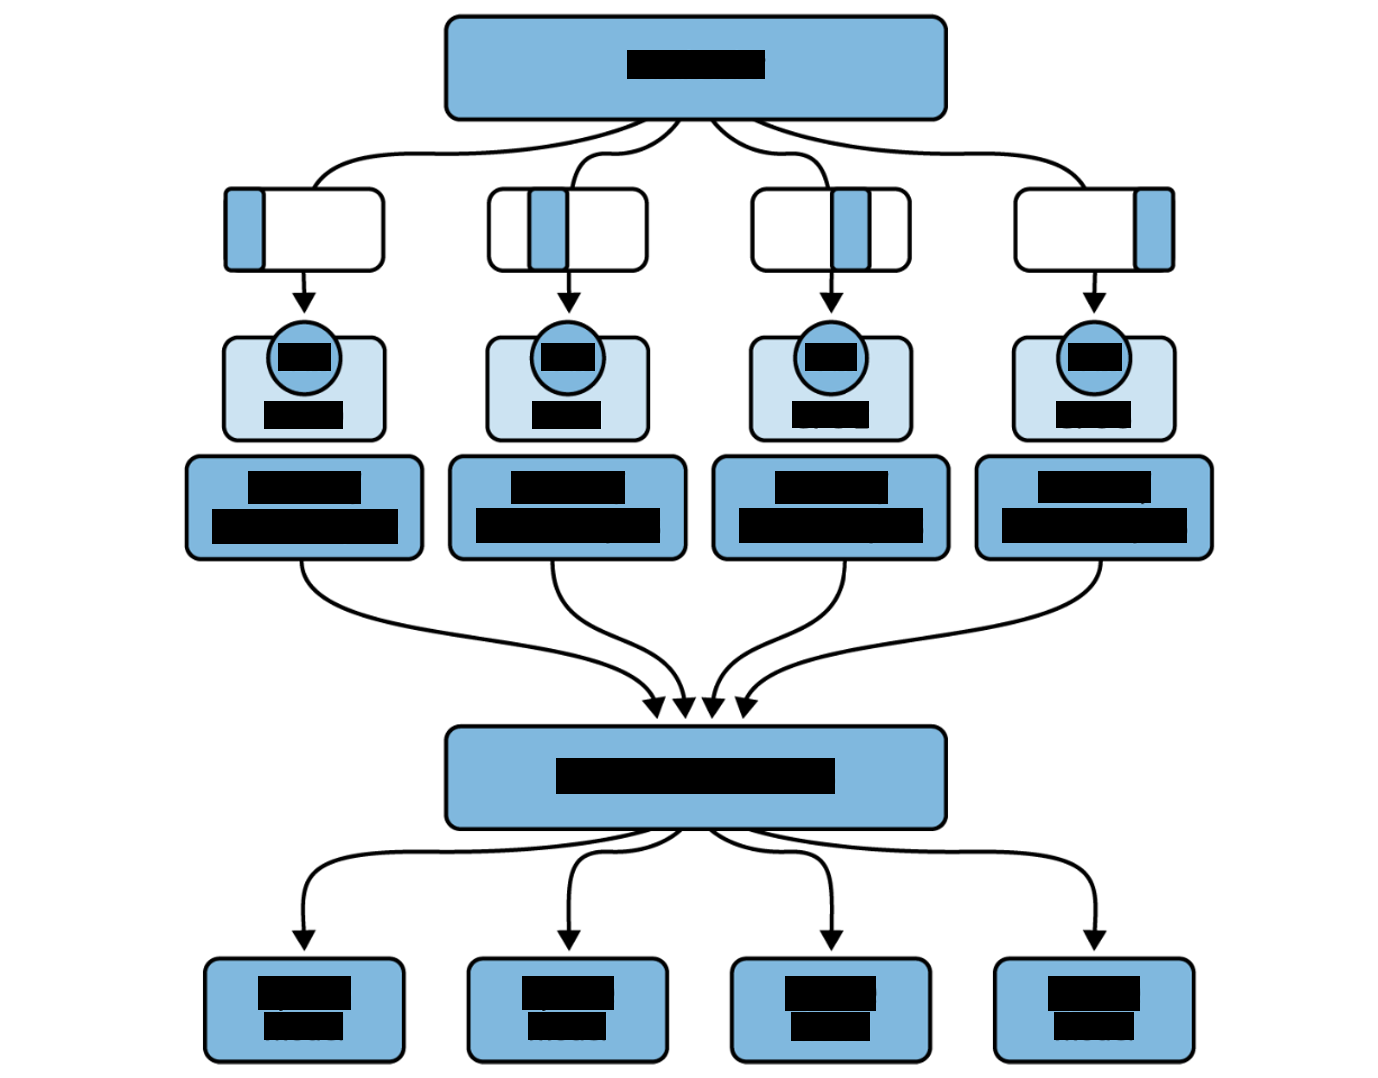

In [15]:
from PIL import Image
import io
images = get_images_by_prompt_id(prompt_id)
view_images=[]
for node_id in images:
      for image_data in images[node_id]:
        image = Image.open(io.BytesIO(image_data))
        view_images.append(image)
        
for image in view_images:
    image.show()   

### 生视频test

In [17]:
import time
import json
import uuid
import json
import base64
from PIL import Image
import io

WORKING_DIR="output_video"
def image_to_base64(image_path):
    try:
        with open(image_path, "rb") as image_file:
            # 读取图像文件
            image_data = image_file.read()
            # 将图像数据转换为Base64编码
            base64_encoded = base64.b64encode(image_data).decode('utf-8')
            return base64_encoded
    except IOError:
        print(f"无法读取文件: {image_path}")
        return None
    
    
def show_gif(fname):
    import base64
    from IPython import display
    with open(fname, 'rb') as fd:
        b64 = base64.b64encode(fd.read()).decode('ascii')
    return display.HTML(f'<img src="data:image/gif;base64,{b64}" />')


def generate_video_by_comfyui(prompt_json_file,image_path,user_prompt):   
    
    base64_string = image_to_base64(image_path)
    prompt_text=""
    with open(prompt_json_file) as f:
        prompt_text = json.load(f)
    
    prompt_text['6']['inputs']['text']= user_prompt
    prompt_text['80']['inputs']['base64_data']=base64_string
    
    prompt_id=queue_prompt(prompt_text)['prompt_id']
    print("prompt_id",prompt_id)
    images = get_videos_by_prompt_id(prompt_id)
    GIF_LOCATION=None
    for node_id in images:
        for image_data in images[node_id]:
            GIF_LOCATION = "{}/Comfyui_{}.mp4".format(WORKING_DIR, node_id)
            print(GIF_LOCATION)
            with open(GIF_LOCATION, "wb") as binary_file:
                # Write bytes to file
                binary_file.write(image_data)
    

    show_gif(GIF_LOCATION)



In [15]:
prompt_json_file="./sample_workflows/ltxv_image_to_video.json"
image_path = "./20250106053346_shot_0.png"
user_prompt = "Chinese ancient style girl wearing cheongsam, smiling"
generate_video_by_comfyui(prompt_json_file,image_path,user_prompt)

prompt_id 70d1710a-e9d6-4ee7-8180-b7c715aadd06
output_video/Comfyui_81.mp4


In [18]:
show_gif("output_video/Comfyui_81.mp4")